In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tomllib
import plt_config

# Visualizing the eigenvalues from empirical observability gramian

In [2]:
try:
    diag_values = np.load("../scripts/variables/diag_values_01.npy")
    eig_values = np.load("../scripts/variables/eig_values_01.npy")
except Exception:
    print("Run 01_Observability_Analysis.py")

In [3]:
with open("../config.toml", "rb") as f:
    cfg = tomllib.load(f)

curr_module = "01"
num_patients = cfg[curr_module]["num_patients"]
threshold = cfg[curr_module]["threshold"]
percent_states_over_threshold = np.sum(eig_values > threshold) / len(eig_values)
print("Percent of eigenvalues over threshold: ", percent_states_over_threshold)

Percent of eigenvalues over threshold:  1.268


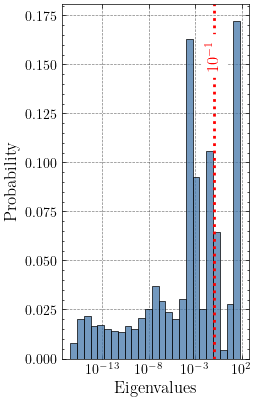

In [4]:
fig, ax = plt.subplots(figsize=(2.55, 4))
sns.histplot(
    eig_values.flatten(),
    stat="probability",
    bins=25,
    ax=ax,
    log_scale=True,
    legend=False,
    kde=False,
)
ax.axvline(threshold, color="red", linestyle=":", linewidth=2)
ax.text(
    threshold,
    ax.get_ylim()[1] * 0.90,
    r"$10^{-1}$",
    color="red",
    rotation=90,
    va="top",
    ha="center",
    backgroundcolor="white",
)
ax.set_xlabel("Eigenvalues")
fig.savefig("figures/5_3.pdf", format="pdf")

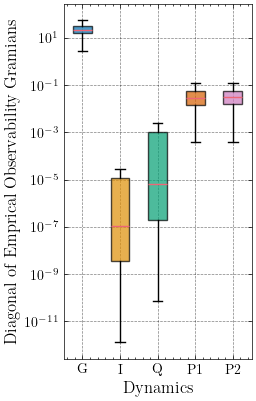

In [5]:
states = ["G", "I", "Q", "P1", "P2"]
palette = sns.color_palette("colorblind", len(states))
fig, ax = plt.subplots(figsize=(2.55, 4))
bp = ax.boxplot(diag_values, tick_labels=states, patch_artist=True, showfliers=False)
ax.set_yscale("log")
ax.set_xlabel("Dynamics")
ax.set_ylabel("Diagonal of Emprical Observability Gramians")
for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
fig.savefig("figures/5_7.pdf", format="pdf")